# <span style="color:#1f77b4;">**🫧CLUSTERING THE POWER PLANTS🫧**</span>

This notebook implements the **ML-based clustering component** of the ABM–LLM–ML platform.  
The goal is to group Indonesian coal-fired power plants into a small number of **behavioural
profiles** based on their technical and emissions-related characteristics. These clusters will
later be mapped to **PowerPlant** agent types in the Mesa simulation, providing empirically
grounded heterogeneity for the agent-based model.


## **🧱 Code Structure Overview**

1. **Exploratory Data Analysis (EDA)**  
   Load the dataset, inspect distributions, correlations, and missing values.

2. **Feature engineering**  
   Select, clean, transform, and scale variables used for clustering.

3. **Clustering Method 1: K-Means**
   Cluster selection, model fitting and interpretation.

4. **Clustering Method 2: K-Prototypes**  
   Extend clustering to include *Combustion technology* as a categorical feature.

5. **Comparison and Selection for Simulation**  
   Compare K-Means vs K-Prototypes and select the clustering used in the ABM.


## **🔎EXPLORATORY DATA ANALYSIS (EDA)🔍**

In this section, we explore the plant-level dataset to understand its main patterns and limitations. We inspect variable distributions, correlations, and missing values to determine which features are informative for clustering and what preprocessing steps are required.

### **1. Data Source and Structure**

Each row in the dataset represents **one coal-fired power plant (or unit)**.  
Available variables include:

🔍Technical characteristics: capacity, plant age, heat rate, remaining lifetime.

🔍Emissions indicators: annual CO₂, emission intensity.

🔍Categorical descriptors: combustion technology, coal type, operational status.

The purpose of this subsection is to understand the dataset structure before performing any feature selection or transformation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

# Load data
df_unfiltered = pd.read_csv("coal_plants_indonesia_enriched.csv")

# Filter only the operating plants
df = df_unfiltered[df_unfiltered["Status"].astype(str).str.lower() == "operating"].copy()

print("Rows:", df.shape[0], "| Columns:", df.shape[1])
df.head()


Rows: 276 | Columns: 51


,GEM unit/phase ID,GEM location ID,Country/Area,Wiki URL,Plant name,Unit name,Plant name (other),Plant name (local),Owner,Owner GEM Entity ID,Parent,Parent GEM Entity ID,Capacity (MW),Status,Start year,Retired year,Planned retirement,Combustion technology,Coal type,Coal source,Conversion to (fuel),Conversion to (GEM unit ID),Alternate Fuel,Location,"Local area (taluk, county)","Major area (prefecture, district)","Subnational unit (province, state)",Subregion,Region,Latitude,Longitude,Location accuracy,Permits,Permit Date,Permit Parsed,Captive,Captive industry use,Captive residential use,China Capacity Payment Recipient,CHP,Plant age (years),Capacity factor,Heat rate (Btu per kWh),Emission factor (kg of CO2 per TJ),Annual CO2 (million tonnes / annum),Remaining plant lifetime (years),Lifetime CO2 (million tonnes),province_norm,zone,est_generation_MWh,emis_intensity_t_per_MWh
2,G100000100040,L100000102708,Indonesia,https://www.gem.wiki/Adipala_power_station,Adipala power station,Unit 1,"Pembangkit Listrik Tenaga Uap Adipala, 印尼国电阿迪帕拉电站",NaN,PT PLN (Persero) [100%],E100000000537 [100%],PT PLN (Persero) [100.0%],E100000000537 [100.0%],660.0,operating,2015.0,NaN,NaN,supercritical,subbituminous,NaN,NaN,NaN,bioenergy,Bunton,Adipala,Cilacap,Central Java,South-eastern Asia,Asia,-7.685942,109.137560,exact,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,0.55,9249.9,96100,2.982400,25,74.560003,Jawa Tengah,Jawa-Madura-Bali,3179880.0,0.937897
8,G100000100142,L100000102773,Indonesia,https://www.gem.wiki/Amamapare_Port_power_station,Amamapare Port power station,Unit 1,NaN,NaN,PT Puncakjaya Power [100%],E100000121062 [100%],PT Puncakjaya Power [100.0%],E100000121062 [100.0%],65.0,operating,1998.0,NaN,2027.0,subcritical,unknown,Pinang coal deposit,fossil gas: LNG,G100001018115,NaN,Amamapare,Mimika Timur Jauh,Mimika,Papua,South-eastern Asia,Asia,-4.827752,136.839082,exact,NaN,NaN,NaN,other metals & mining,power,NaN,NaN,NaN,27,0.55,12182.8,96100,0.386852,2,0.773705,Papua,Maluku-Papua-NTT,313170.0,1.235280
9,G100000100143,L100000102773,Indonesia,https://www.gem.wiki/Amamapare_Port_power_station,Amamapare Port power station,Unit 2,NaN,NaN,PT Puncakjaya Power [100%],E100000121062 [100%],PT Puncakjaya Power [100.0%],E100000121062 [100.0%],65.0,operating,1998.0,NaN,2027.0,subcritical,unknown,Pinang coal deposit,NaN,NaN,NaN,Amamapare,Mimika Timur Jauh,Mimika,Papua,South-eastern Asia,Asia,-4.827752,136.839082,exact,NaN,NaN,NaN,other metals & mining,power,NaN,NaN,NaN,27,0.55,12182.8,96100,0.386852,2,0.773705,Papua,Maluku-Papua-NTT,313170.0,1.235280
10,G100000100144,L100000102773,Indonesia,https://www.gem.wiki/Amamapare_Port_power_station,Amamapare Port power station,Unit 3,NaN,NaN,PT Puncakjaya Power [100%],E100000121062 [100%],PT Puncakjaya Power [100.0%],E100000121062 [100.0%],65.0,operating,1999.0,NaN,2027.0,subcritical,unknown,Pinang coal deposit,NaN,NaN,NaN,Amamapare,Mimika Timur Jauh,Mimika,Papua,South-eastern Asia,Asia,-4.827752,136.839082,exact,NaN,NaN,NaN,other metals & mining,power,NaN,NaN,NaN,26,0.55,12182.8,96100,0.386852,2,0.773705,Papua,Maluku-Papua-NTT,313170.0,1.235280
13,G100000100180,L100000102759,Indonesia,https://www.gem.wiki/Amurang_power_station,Amurang power station,Unit 1,Sulut 2,NaN,PT PLN (Persero) [100%],E100000000537 [100%],PT PLN (Persero) [100.0%],E100000000537 [100.0%],30.0,operating,2012.0,NaN,NaN,subcritical,unknown,NaN,NaN,NaN,bioenergy,Amurang,NaN,South Minahasa,North Sulawesi,South-eastern Asia,Asia,1.182502,124.480564,exact,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,0.55,11312.6,96100,0.165794,22,3.647466,Sulawesi Utara,Sulawesi,144540.0,1.147045


### **2. Data Types and Missing Values**

In this step, we examine the **structure and completeness** of the dataset to assess its
suitability for clustering.

Specifically, we:

🔍 Inspect data types to distinguish between *numeric* and *categorical* variables.

🔍 Compute the percentage of missing values** for each column.

🔍 Identify variables with:
  - very high missingness,
  - near-zero variance,
  - or structural issues that limit their analytical usefulness.

These diagnostics guide several important modelling decisions:

🔍Which variables are usable for clustering, either directly or after preprocessing.

🔍Which fields should be dropped, due to:
  - excessive missing values,
  - lack of variation across plants,
  - or redundancy with other variables.

This step ensures that subsequent feature engineering and clustering are based on
**informative and reliable inputs**, improving robustness and interpretability.

In [2]:
print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values (%) ---")
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct



--- Data Types ---
GEM unit/phase ID                       object
GEM location ID                         object
Country/Area                            object
Wiki URL                                object
Plant name                              object
Unit name                               object
Plant name (other)                      object
Plant name (local)                     float64
Owner                                   object
Owner GEM Entity ID                     object
Parent                                  object
Parent GEM Entity ID                    object
Capacity (MW)                          float64
Status                                  object
Start year                             float64
Retired year                           float64
Planned retirement                     float64
Combustion technology                   object
Coal type                               object
Coal source                             object
Conversion to (fuel)                    

Retired year                           100.000000
Plant name (local)                     100.000000
Permit Date                            100.000000
Permit Parsed                          100.000000
Captive residential use                100.000000
China Capacity Payment Recipient       100.000000
Permits                                100.000000
Conversion to (GEM unit ID)             99.275362
Conversion to (fuel)                    99.275362
CHP                                     98.550725
Coal source                             94.565217
Planned retirement                      92.028986
Alternate Fuel                          70.652174
Captive industry use                    59.420290
Captive                                 50.362319
Location                                34.782609
Local area (taluk, county)              21.014493
Plant name (other)                      18.478261
Major area (prefecture, district)       17.028986
zone                                    13.405797


### **3. Distribution of Key Numeric Features**

We examine the distributions of key numeric variables to identify:

- skewness (e.g. many small plants vs a few very large plants),
- extreme outliers,
- variables with little or no variation.

These patterns inform decisions such as:
- applying log-transformations,
- clipping unrealistic values,
- or excluding variables from clustering.


In [3]:
numeric_candidates = [
    "Capacity (MW)",
    "Plant age (years)",
    "Capacity factor",
    "Heat rate (Btu per kWh)",
    "Emission factor (kg of CO2 per TJ)",
    "Annual CO2 (million tonnes / annum)",
    "Remaining plant lifetime (years)",
    "Lifetime CO2 (million tonnes)",
    "emis_intensity_t_per_MWh",
]

numeric_cols = [c for c in numeric_candidates if c in df.columns]

df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Capacity (MW),276.0,209.081884,2.185634e+02,30.000000,60.000000,121.000000,318.750000,1000.000000
Plant age (years),276.0,10.724638,9.104858e+00,0.000000,4.000000,8.000000,13.000000,41.000000
Capacity factor,276.0,0.550000,1.112240e-16,0.550000,0.550000,0.550000,0.550000,0.550000
Heat rate (Btu per kWh),276.0,10560.598188,9.429029e+02,8272.000000,10326.000000,10442.400000,11312.600000,12617.900000
Emission factor (kg of CO2 per TJ),276.0,96262.681159,9.914280e+02,94600.000000,96100.000000,96100.000000,96100.000000,101000.000000
Annual CO2 (million tonnes / annum),276.0,1.012668,9.574145e-01,0.151335,0.327892,0.649255,1.606926,4.041061
Remaining plant lifetime (years),276.0,24.246377,8.980230e+00,2.000000,21.000000,27.000000,31.000000,35.000000
Lifetime CO2 (million tonnes),276.0,23.966408,2.433684e+01,0.431489,7.314507,15.681215,33.668921,123.220047
emis_intensity_t_per_MWh,276.0,1.072756,9.808695e-02,0.838743,1.047009,1.058811,1.147045,1.298265


C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


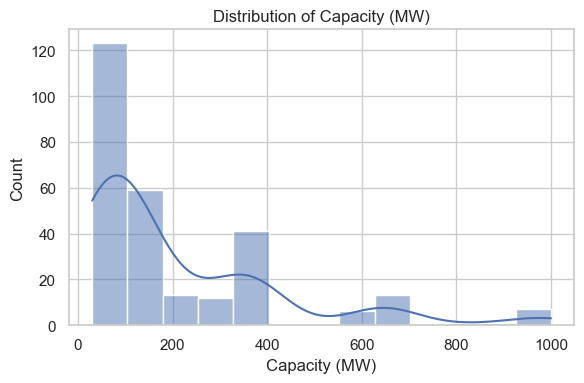

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


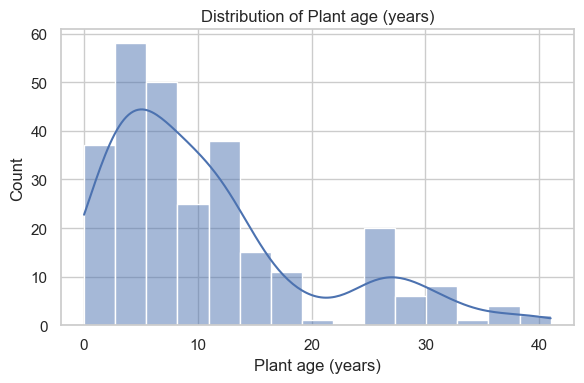

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


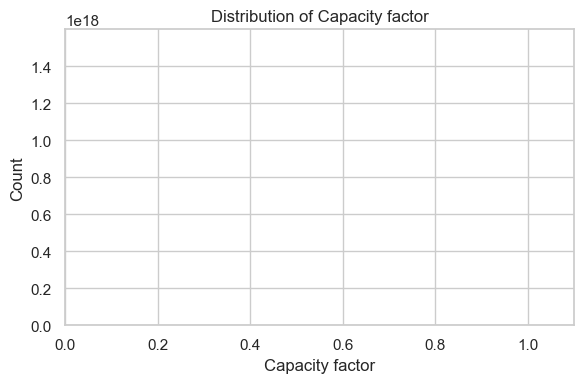

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


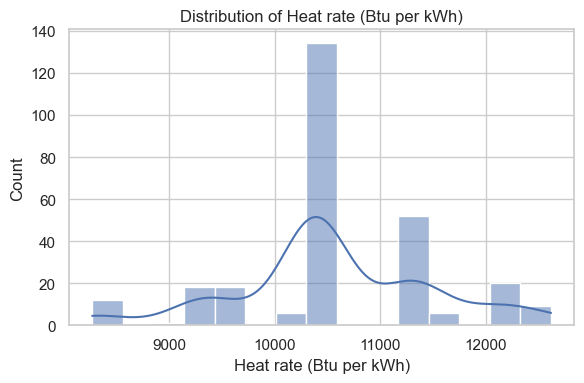

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


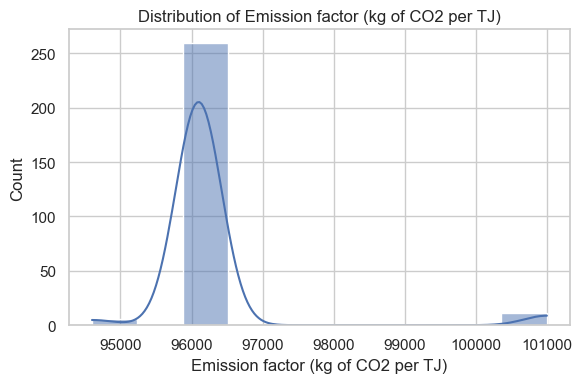

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


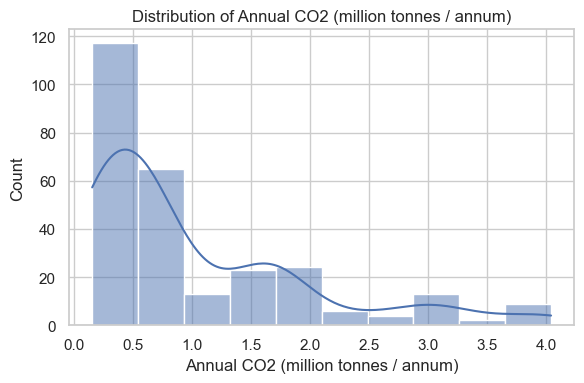

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


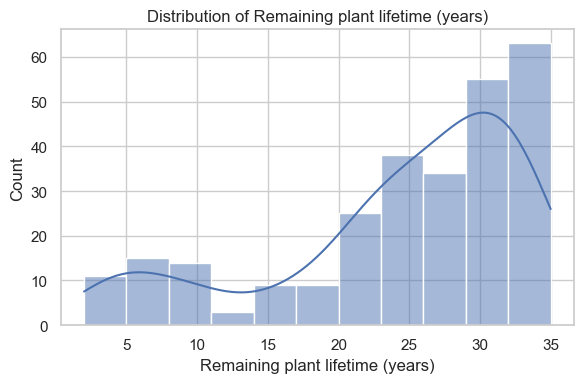

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


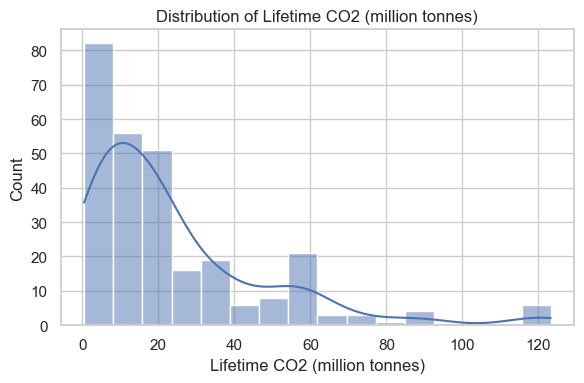

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


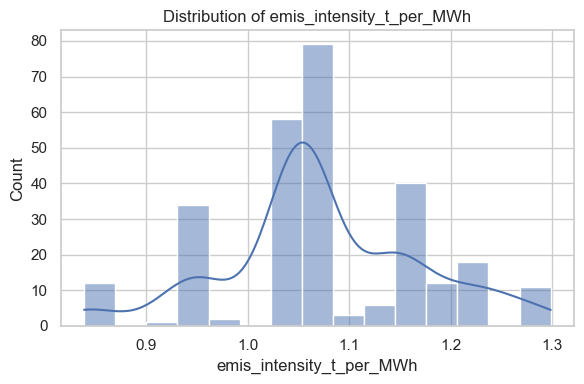

In [4]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


### 4. Correlation Structure and Categorical Distributions

We analyse:

- **Correlation structure** among numeric variables to detect redundancy  
  (e.g. annual CO₂ as a function of capacity and heat rate).
- **Capacity vs emission intensity** to assess scale–efficiency relationships.
- **Categorical distributions** to identify rare, missing, or uninformative categories.

These insights directly inform feature selection and feature engineering.


C:\Users\HP\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


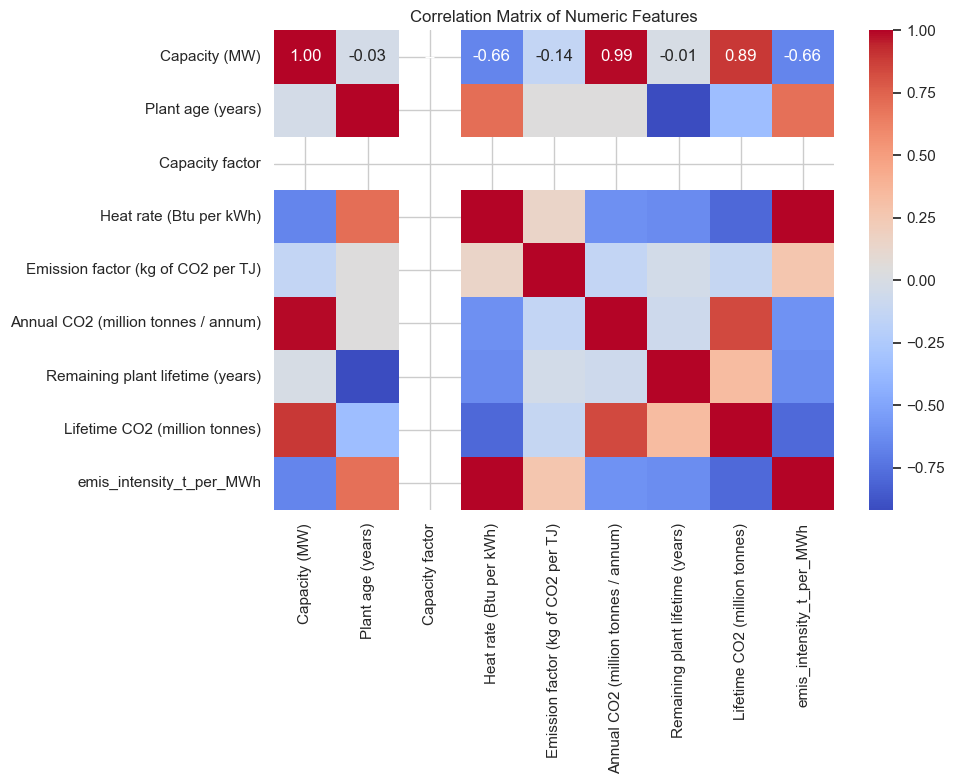

In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()


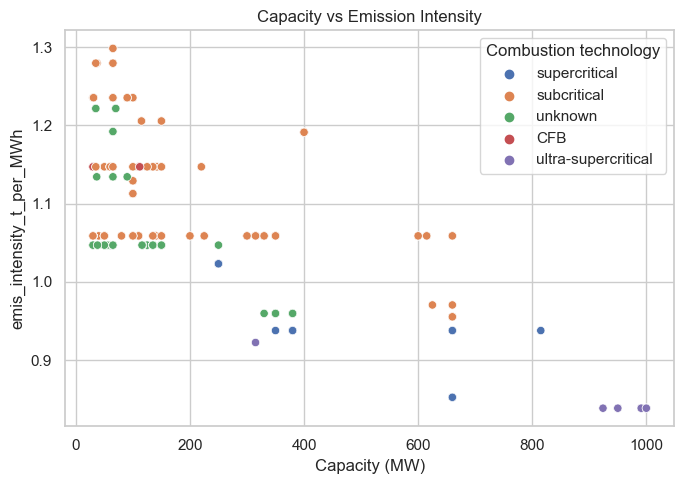

In [6]:
if "Capacity (MW)" in df.columns and "emis_intensity_t_per_MWh" in df.columns:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=df,
        x="Capacity (MW)",
        y="emis_intensity_t_per_MWh",
        hue="Combustion technology" if "Combustion technology" in df.columns else None
    )
    plt.title("Capacity vs Emission Intensity")
    plt.tight_layout()
    plt.show()


In [7]:
categorical_cols = [
    "Combustion technology",
    "Coal type",
    "CHP",
    "Captive",
    "zone",
    "Zone",
]

categorical_cols = [c for c in categorical_cols if c in df.columns]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].astype("string").fillna("Missing").value_counts().head(15))



--- Combustion technology ---
Combustion technology
subcritical            159
unknown                 75
supercritical           28
ultra-supercritical      9
CFB                      5
Name: count, dtype: Int64

--- Coal type ---
Coal type
unknown          215
subbituminous     44
lignite           11
bituminous         6
Name: count, dtype: Int64

--- CHP ---
CHP
Missing    272
yes          4
Name: count, dtype: Int64

--- Captive ---
Captive
Missing                  139
nickel                    70
pulp & paper              20
aluminum                  10
other metals & mining      9
aluminum, nickel           9
chemicals                  5
industrial park            5
textiles                   4
cement & building          3
iron & steel               2
Name: count, dtype: Int64

--- zone ---
zone
Jawa-Madura-Bali    76
Sulawesi            74
Sumatra             58
Missing             37
Kalimantan          28
Maluku-Papua-NTT     3
Name: count, dtype: Int64


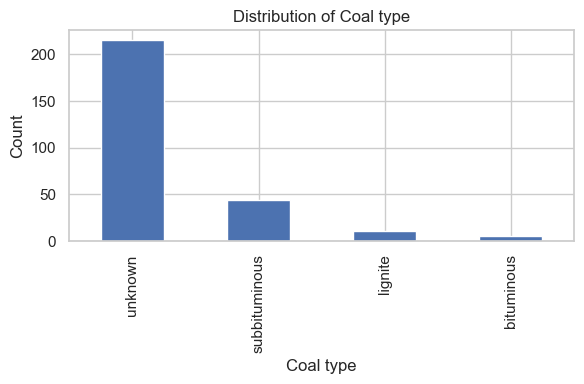

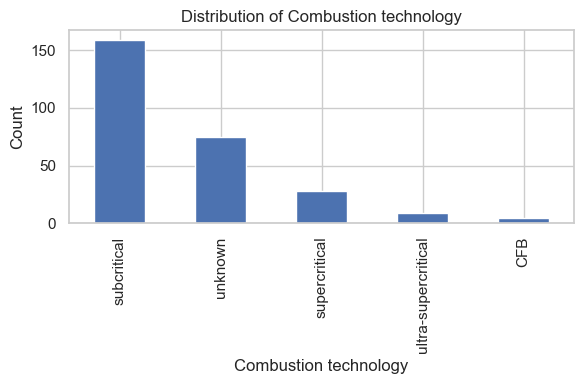

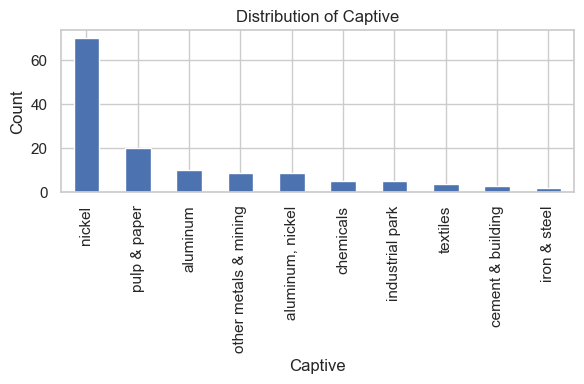

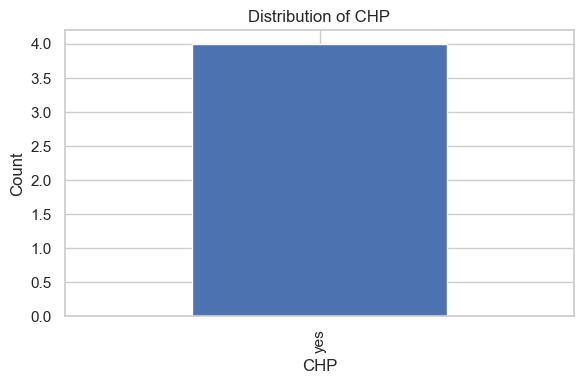

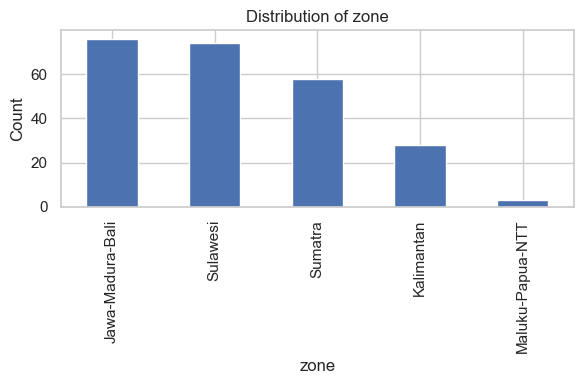

In [8]:
cat_cols_simple = ['Coal type', 'Combustion technology', 'Captive', 'CHP', 'zone']
cat_cols_simple = [c for c in cat_cols_simple if c in df.columns]

for col in cat_cols_simple:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


### 5. Key Insights from EDA

**⭕Overall Data Structure⭕**

- The dataset comprises 276 operating coal-fired power plants in Indonesia.
- Core technical and emissions-related variables are complete, while administrative and policy-related attributes exhibit substantial missingness.
- The data are therefore well suited for unsupervised clustering based on physical, operational, and emissions characteristics.

**🔢Numeric features**

- **Plant capacity** and emissions-related variables exhibit strong right-skewness, indicating that a small number of large plants account for a disproportionate share of generation and CO₂ emissions.
- **Plant age** exhibits strong right skewness, indicating a concentration of relatively new generating units.
- **Heat rate** shows substantial variability and is therefore a salient discriminator for clustering.
- **Emission factor** displays minimal variance and provides limited discriminatory power.
- **Capacity factor** is nearly constant (≈ 0.55) and thus excluded from clustering.
- **Remaining lifetime** is highly left-skewed, reflecting a prevalence of newer assets; its inclusion is optional depending on analytical scope.
- **Emissions intensity** shows moderate dispersion, reflecting efficiency and technology differences while remaining interpretable at the plant level.
- **Annual and lifetime CO₂ emissions** are highly correlated with capacity and heat rate, suggesting redundancy.

**🍣Categorical features**
- **Combustion technology** captures meaningful technological heterogeneity and is retained as an optional categorical feature.
- **Coal type and CHP status** suffer from extensive missingness or dominance by a single category and are excluded.
  
**🎨 Recommended feature set**

Based on the EDA, the recommended features are those that (i) exhibit substantial variability, (ii) have low missingness, (iii) represent distinct physical or operational dimensions, and (iv) minimize redundancy:
- **Plant capacity**
- **Plant age**
- **Heat rate**
- **Emissions intensity**
- **Combustion technology (categorical)**
  
This feature set balances interpretability, statistical signal, and computational suitability for clustering.

## **⚙️FEATURE ENGINEERING⚙️**

Based on the EDA, we retain the following features:

**Numeric features**
- Capacity (MW)
- Plant age (years)
- Heat rate (Btu/kWh)
- Emission intensity (tCO₂/MWh)

In the following code:
* all selected numeric variables are first coerced into numeric format, with missing values imputed using the median of each feature to ensure robustness to outliers.
* To reduce skewness and stabilize variance, logarithmic transformations (log1p) are applied to all numeric features—capacity, plant age, heat rate, and emissions intensity. This transformation improves feature symmetry and reduces the influence of extreme values.
* The transformed features are subsequently scaled using a RobustScaler, which standardizes variables based on the median and interquartile range. This scaling approach is well suited to heterogeneous power plant data and further limits sensitivity to outliers.

Finally, Principal Component Analysis (PCA) is applied to the scaled feature matrix to reduce dimensionality and support visualization and clustering, while retaining most of the variance present in the original feature space.

Overall, this preprocessing pipeline enhances comparability across features and supports stable and interpretable clustering outcomes.

In [9]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

features = [
    "Capacity (MW)",
    "Plant age (years)",
    "Heat rate (Btu per kWh)",
    "emis_intensity_t_per_MWh"
]

missing = [c for c in features if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_feat = df[features].copy()


In [10]:
for c in features:
    df_feat[c] = pd.to_numeric(df_feat[c], errors="coerce")
    df_feat[c] = df_feat[c].fillna(df_feat[c].median())


In [11]:
df_feat["log_capacity"] = np.log1p(df_feat["Capacity (MW)"])
df_feat["log_age"] = np.log1p(df_feat["Plant age (years)"])
df_feat["heat_rate"] = np.log1p(df_feat["Heat rate (Btu per kWh)"])
df_feat["emission_int"] = np.log1p(df_feat["emis_intensity_t_per_MWh"])

df_feat = df_feat.drop(columns=[
    "Capacity (MW)",
    "Plant age (years)",
    "Heat rate (Btu per kWh)",
    "emis_intensity_t_per_MWh"
])


In [12]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_feat)


In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Final feature matrix shape (after PCA):", X_pca.shape)
print("Engineered features (pre-PCA):", list(df_feat.columns))
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.sum())


Final feature matrix shape (after PCA): (276, 2)
Engineered features (pre-PCA): ['log_capacity', 'log_age', 'heat_rate', 'emission_int']
Explained variance ratio: [0.82555057 0.1341107 ]
Cumulative explained variance: 0.9596612748753457


## **💠 CLUSTERING METHOD 1: K-Means💠**

We first apply **K-Means clustering** using numeric features only. This serves as the baseline typology for the agent-based model.

### **1. Cluster Selection**

The number of clusters is selected using:
- the **Elbow method** (within-cluster inertia),
- **Silhouette scores** (cluster separation).


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

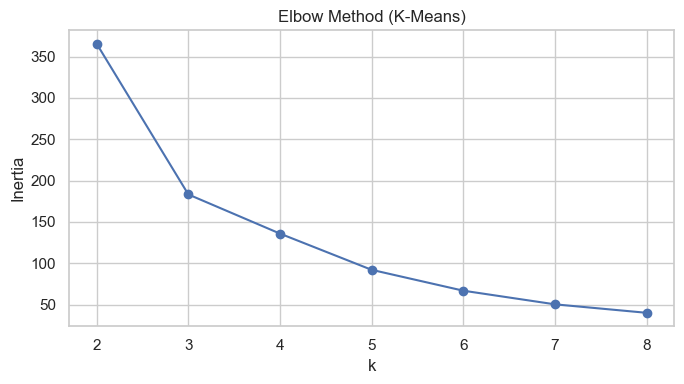

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

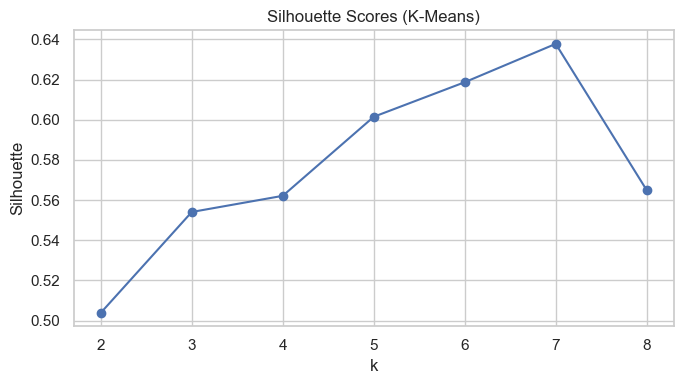

k=2, silhouette=0.5039
k=3, silhouette=0.5541
k=4, silhouette=0.5621
k=5, silhouette=0.6015
k=6, silhouette=0.6187
k=7, silhouette=0.6378
k=8, silhouette=0.5649


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 9)

# Elbow
inertias = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method (K-Means)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# Silhouette
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), sil_scores, marker="o")
plt.title("Silhouette Scores (K-Means)")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

for i, k in enumerate(K_range):
    print(f"k={k}, silhouette={sil_scores[i]:.4f}")


### **2. Model fitting and interpretation**


Based on the elbow criterion and silhouette analysis, we select **k = 5** as a parsimonious compromise between statistical separation and behavioural resolution for the agent-based model.

While the silhouette score continues to improve marginally for larger values of *k*, increasing the number of clusters beyond five yields diminishing interpretability gains and introduces unnecessary complexity in agent typologies. The choice of *k = 5* therefore balances clustering performance with the practical requirements of defining distinct and interpretable power plant agent types.

For the selected clustering solution, we report:
- Cluster sizes
- Cluster-level summary statistics in original units (capacity, age, heat rate, and emissions intensity)
- Cluster-labelled plant-level data for direct use in the agent-based simulation

All outputs are exported as CSV files to ensure transparency and reproducibility.


In [15]:
# K-MEANS (PCA space)

best_k = 5

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster_kmeans"] = kmeans.fit_predict(X_pca)

print("\n[K-Means] Cluster size:")
print(df["cluster_kmeans"].value_counts().sort_index())

# ---- "Centroids" in original units (robust representative) ----
# NOTE: Since KMeans was fit in PCA space, cluster_centers_ are in PCA units.
# For interpretability/ABM, we report medians in original units as cluster representatives.
summary_features = [
    "Capacity (MW)",
    "Plant age (years)",
    "Heat rate (Btu per kWh)",
    "emis_intensity_t_per_MWh"
]

kmeans_centroids_original = (
    df.groupby("cluster_kmeans")[summary_features]
      .median()
      .rename(columns={
          "Capacity (MW)": "Capacity (MW) [median]",
          "Plant age (years)": "Plant age (years) [median]",
          "Heat rate (Btu per kWh)": "Heat rate (Btu per kWh) [median]",
          "emis_intensity_t_per_MWh": "emis_intensity_t_per_MWh [median]"
      })
)

print("\n[K-Means] Cluster centroids (original units; median representatives):")
print(kmeans_centroids_original)

# ---- Summary stats on original columns ----
kmeans_summary = df.groupby("cluster_kmeans")[summary_features].agg(["mean", "median", "min", "max"])
print("\n[K-Means] Ringkasan per cluster:")
print(kmeans_summary)

# ---- Save outputs ----
df.to_csv("coal_plants_with_kmeans_clusters.csv", index=False)
kmeans_centroids_original.to_csv("kmeans_cluster_centroids_original_units.csv")
kmeans_summary.to_csv("kmeans_cluster_summary.csv")

print("\n[K-Means] Files saved:")
print("- coal_plants_with_kmeans_clusters.csv")
print("- kmeans_cluster_centroids_original_units.csv")
print("- kmeans_cluster_summary.csv")



[K-Means] Cluster size:
cluster_kmeans
0     43
1     52
2    114
3     35
4     32
Name: count, dtype: int64

[K-Means] Cluster centroids (original units; median representatives):
                Capacity (MW) [median]  Plant age (years) [median]  \
cluster_kmeans                                                       
0                                380.0                         3.0   
1                                 95.0                        12.0   
2                                100.0                         5.0   
3                                 65.0                        28.0   
4                                350.0                        14.0   

                Heat rate (Btu per kWh) [median]  \
cluster_kmeans                                     
0                                         9249.9   
1                                        11312.6   
2                                        10326.0   
3                                        12182.8   
4              

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


**CLUSTERING RESULT SUMMARY**

1. **Overall Model Structure**
   * Number of clusters: 5
   * Total plants clustered: 276
   * Cluster sizes: Well distributed, capturing distinct operational profiles
   * Method: K-Means on numerical variables only
   * Centroids: Represented using median values, improving robustness to outliers

2. **Key Variables Defining the Clusters**
   * The clustering is driven by four continuous dimensions:
   * Capacity (MW)
   * Plant age (years)
   * Heat rate (Btu/kWh) – proxy for efficiency
   * Emission intensity (tCO₂/MWh)
   These variables jointly separate plants by scale, vintage, efficiency, and environmental performance.

3. **Cluster-by-Cluster Interpretation**
   * Cluster 0 – Large, New, High-Efficiency Plants
     * Size: 43
     * Capacity: Very large (median ~380 MW; up to 1000 MW)
     * Age: Very young (~3 years)
     * Efficiency: Best (lowest heat rate)
     * Emissions: Lowes
     * Interpretation: Modern, large-scale plants with excellent efficiency and low emissions, representing the best-performing segment of the fleet.

   * Cluster 1 – Small, Mid-Age, High-Emission Plants
     * Size: 52
     * Capacity: Small (~95 MW)
     * Age: Mid-aged (~12 years)
     * Efficiency: Poor
     * Emissions: High
     * Interpretation: Smaller plants with weak thermal performance, resulting in elevated emissions despite not being particularly old.

   * Cluster 2 – Small, Young, Average-Performance Plants
     * Size: 114 (largest cluster)
     * Capacity: Small–medium (~100 MW)
     * Age: Young (~5 years)
     * Efficiency: Moderate
     * Emissions: Medium
     * Interpretation: Recently built but technologically average plants, forming the baseline profile of the system.

   * Cluster 3 – Small, Old, Worst-Performing Plants
     * Size: 35
     * Capacity: Small (~65 MW)
     * Age: Very old (~28 years)
     * Efficiency: Worst (highest heat rate)
     * Emissions: Highest
     * Interpretation: Aging, inefficient plants with severe performance and environmental drawbacks—clear candidates for retirement.

   * Cluster 4 – Large, Mature, Conventional Plants
     * Size: 32
     * Capacity: Large (~350 MW)
     * Age: Mid-aged (~14 years)
     * Efficiency: Fair
     * Emissions: Medium
     * Interpretation: Established large plants with acceptable but not outstanding performance, likely forming the core baseload segment.

4. **System-Level Insights**
   * Efficiency strongly scales with plant size and age: newer and larger units perform best.
   * Small plants are highly heterogeneous: performance ranges from acceptable to extremely poor.
   * Age amplifies inefficiency: the oldest plants exhibit the highest emissions regardless of size.
   * Clear stratification: clusters form a logical gradient from modern–efficient to legacy–polluting assets.

5. **Final Takeaway**
   * The K-Means clustering cleanly segments coal plants into five distinct performance archetypes, enabling straightforward identification of best performers, average assets, and high-priority retirement candidates based solely on quantitative operational and environmental characteristics.

## **💠 CLUSTERING METHOD 2: K-Prototypes💠**

To complement the numeric-only K-Means clustering, we apply **K-Prototypes** to jointly cluster power plants based on **engineered numeric features** (capacity, age, heat rate, and emissions intensity) and a **categorical technology attribute** (combustion technology).

Numeric variables are scaled to ensure comparable influence across dimensions, while combustion technology is incorporated to capture discrete technological heterogeneity that may affect emissions performance and policy response. The number of clusters is fixed at **k = 5** to maintain consistency with the K-Means solution and to preserve interpretability of agent archetypes.

The resulting clusters are evaluated in terms of:
- cluster size,
- numeric characteristics in original units,
- and technology composition within each cluster.

This approach enables a technology-aware typology of operating coal-fired power plants that is directly applicable to the agent-based simulation.

In [16]:
import warnings
warnings.filterwarnings("ignore")

from kmodes.kprototypes import KPrototypes
import numpy as np
import pandas as pd


# K-PROTOTYPES (mixed data)

best_kproto = 5
cat_col = "Combustion technology"

if cat_col not in df.columns:
    raise ValueError(f"Column '{cat_col}' not found in df.")

# numeric (scaled) as DataFrame
num_cols = list(df_feat.columns)  # ['log_capacity','log_age','heat_rate','emission_int']
X_num = pd.DataFrame(X_scaled, columns=num_cols, index=df.index).astype(float)

# add categorical
X_kproto = X_num.copy()
X_kproto[cat_col] = (
    df[cat_col]
    .astype("string")
    .fillna("Unknown")
    .replace({"": "Unknown"})
    .astype(str)
)

# mixed matrix
X_mat = X_kproto.to_numpy(dtype=object)
cat_idx = [X_kproto.columns.get_loc(cat_col)]

# fit
kproto = KPrototypes(
    n_clusters=best_kproto,
    init="Cao",
    n_init=10,
    random_state=42,
    verbose=0
)

df["cluster_kproto"] = kproto.fit_predict(X_mat, categorical=cat_idx)

print("\n[K-Prototypes] Cluster size:")
print(df["cluster_kproto"].value_counts().sort_index())

print("\n[K-Prototypes] Fit done.")
print("Cost:", kproto.cost_)
print("Gamma:", kproto.gamma)

# ---- Centroids in original units (from K-Prototypes centroids) ----
# cluster_centroids_ contains [numeric_centroids, categorical_centroids]
centroids_raw = np.array(kproto.cluster_centroids_, dtype=object)

# numeric part (scaled)
num_centroids_scaled = centroids_raw[:, :len(num_cols)].astype(float)

# inverse scale -> engineered numeric units
num_centroids_engineered = scaler.inverse_transform(num_centroids_scaled)

centroids_kp = pd.DataFrame(num_centroids_engineered, columns=num_cols)
centroids_kp.insert(0, "cluster_kproto", range(best_kproto))

# undo log transforms (if these columns exist)
if "log_capacity" in centroids_kp.columns:
    centroids_kp["Capacity (MW)"] = np.expm1(centroids_kp["log_capacity"])
    centroids_kp = centroids_kp.drop(columns=["log_capacity"])

if "log_age" in centroids_kp.columns:
    centroids_kp["Plant age (years)"] = np.expm1(centroids_kp["log_age"])
    centroids_kp = centroids_kp.drop(columns=["log_age"])

# rename engineered columns to match original names (if needed)
centroids_kp = centroids_kp.rename(columns={
    "heat_rate": "Heat rate (Btu per kWh)",
    "emission_int": "emis_intensity_t_per_MWh"
})

# add categorical centroid (mode)
cat_centroids = centroids_raw[:, len(num_cols):]
centroids_kp[cat_col] = cat_centroids[:, 0]

# reorder columns (only keep what exists)
ordered_cols = ["cluster_kproto", "Capacity (MW)", "Plant age (years)",
                "Heat rate (Btu per kWh)", "emis_intensity_t_per_MWh", cat_col]
centroids_kp = centroids_kp[[c for c in ordered_cols if c in centroids_kp.columns]]

print("\n[K-Prototypes] Cluster centroids (original/derived units):")
print(centroids_kp)

# ---- Summary stats on original numeric columns (same features as K-Means) ----
summary_features = [
    "Capacity (MW)",
    "Plant age (years)",
    "Heat rate (Btu per kWh)",
    "emis_intensity_t_per_MWh"
]

kproto_summary = df.groupby("cluster_kproto")[summary_features].agg(["mean", "median", "min", "max"])
print("\n[K-Prototypes] Ringkasan per cluster:")
print(kproto_summary)

# ---- Categorical summaries ----
tech_mode = df.groupby("cluster_kproto")[cat_col].agg(lambda s: s.value_counts().index[0])
print("\n[K-Prototypes] Dominant combustion technology (mode) per cluster:")
print(tech_mode)

tech_share = (
    df.groupby("cluster_kproto")[cat_col]
      .value_counts(normalize=True)
      .rename("share")
      .reset_index()
      .sort_values(["cluster_kproto", "share"], ascending=[True, False])
)
print("\n[K-Prototypes] Combustion technology shares per cluster:")
print(tech_share)

# ---- Save outputs ----
df.to_csv("coal_plants_with_kprototypes.csv", index=False)
centroids_kp.to_csv("kproto_cluster_centroids.csv", index=False)
kproto_summary.to_csv("kproto_cluster_summary.csv")
tech_mode.to_csv("kproto_tech_mode.csv")
tech_share.to_csv("kproto_tech_share.csv", index=False)

print("\n[K-Prototypes] Files saved:")
print("- coal_plants_with_kprototypes.csv")
print("- kproto_cluster_centroids.csv")
print("- kproto_cluster_summary.csv")
print("- kproto_tech_mode.csv")
print("- kproto_tech_share.csv")



[K-Prototypes] Cluster size:
cluster_kproto
0    114
1     32
2     52
3     43
4     35
Name: count, dtype: int64

[K-Prototypes] Fit done.
Cost: 163.03496230014633
Gamma: 0.417981487239879

[K-Prototypes] Cluster centroids (original/derived units):
   cluster_kproto  Capacity (MW)  Plant age (years)  Heat rate (Btu per kWh)  \
0               0      84.701156           4.615935                 9.246810   
1               1     425.329874          16.413852                 9.237412   
2               2      76.845801          12.021869                 9.332468   
3               3     487.572994           2.798818                 9.108873   
4               4      73.944393          29.277601                 9.409050   

   emis_intensity_t_per_MWh Combustion technology  
0                  0.719268           subcritical  
1                  0.712951           subcritical  
2                  0.766177           subcritical  
3                  0.650593         supercritical  
4      

**CLUSTERING RESULT SUMMARY**

1. Overall Model Quality
   * Number of clusters: 5
   * Total plants clustered: 276
   * Cost: 163.03 → indicates reasonable compactness given mixed numeric–categorical data\Gamma (0.418): Balanced influence between numerical features and combustion technology
   * Cluster sizes: Uneven but meaningful, suggesting real structural differences rather than forced splits

2. Key Dimensions Driving the Clusters
   The clusters are primarily differentiated by:
   * Plant capacity (MW) – small vs large units
   * Plant age – new, mid-life, and very old plants
   * Thermal efficiency (heat rate)
   * Emission intensity (tCO₂/MWh)
   * Combustion technology – especially supercritical vs subcritical
    
3. Cluster-by-Cluster Interpretation
   * **Cluster 0 – Small, Young, Inefficient Subcritical Plants**
     - Size: 114 (largest cluster)
     - Capacity: Small–medium (~ 100 MW)
     - Age: Young (~5 years)
     - Technology: Mostly subcritical, with many unknown
     - Efficiency: Moderate heat rate
     - Emissions: Medium–high
     - Interpretation: Newer but relatively small plants that did not adopt advanced technology, leading to average efficiency and emissions.

   * **Cluster 1 – Large, Mature, Conventional Subcritical Plants**
     - Size: 32
     - Capacity: Large (~450 MW)
     - Age: Mid-aged (~17 years)
     - Technology: 100% subcritical
     - Efficiency: Fair
     - Emissions: Medium
     - Interpretation: Classic baseload coal plants—large and reliable, but technologically dated with limited emissions improvement potential.

   * **Cluster 2 – Small, Mid-Age, High-Emission Plants**
     - Size: 52
     - Capacity: Small (~90 MW)
     - Age: Mid-aged (~12 years)
     - Technology: Mostly subcritical
     - Efficiency: Poor (high heat rate)
     - Emissions: High
     - Interpretation: Underperforming plants: relatively small, inefficient, and carbon-intensive—strong candidates for early retirement or retrofit.

   * **Cluster 3 – Large, New, High-Efficiency Plants (Best Performers)**
     - Size: 43
     - Capacity: Very large (~530 MW)
     - Age: Very young (~3–4 years)
     - Technology: Predominantly supercritical / ultra-supercritical
     - Efficiency: Best (lowest heat rate)
     - Emissions: Lowest
     - Interpretation: State-of-the-art coal plants—large-scale, modern, and most efficient. They represent the current technological frontier of coal power.

   * **Cluster 4 – Small, Old, Worst-Performing Plants**
     - Size: 35
     - Capacity: Small (~115 MW)
     - Age: Very old (~30 years)
     - Technology: Mostly subcritical
     - Efficiency: Worst
     - Emissions: Highest
     - Interpretation: Legacy plants—aging, inefficient, and highly polluting. These are the highest-priority candidates for decommissioning.

4. Cross-Cluster Insights
   * Technology matters: Supercritical and ultra-supercritical plants (Cluster 3) clearly outperform subcritical ones.
   * Age alone is not enough: Young plants can still be inefficient if technology choice is poor (Cluster 0).


5. Final Takeaway
   The clustering successfully separates coal plants into distinct operational and environmental archetypes, enabling clear prioritization for retirement, retrofit, or continued operation based on efficiency, emissions, and technology—not capacity alone.

## **⚖️💡 COMPARISON AND SELECTION FOR SIMULATION💡⚖️**

* The clustering results obtained from K-Means (numeric-only) and K-Prototypes (numeric + categorical) are highly consistent in terms of overall structure and cluster sizes, indicating that plant capacity, age, and efficiency dominate the grouping of operating coal-fired power plants.
  
* Across both methods, five comparable plant archetypes emerge, corresponding to combinations of plant scale (large vs. small), vintage (young vs. old), and operational efficiency (low vs. high heat rate). Cluster-level medians for capacity, plant age, heat rate, and emissions intensity are nearly identical between K-Means and K-Prototypes, demonstrating that the inclusion of categorical variables does not distort the underlying numeric clustering.

* The key distinction arises from the explicit incorporation of combustion technology in the K-Prototypes model. Technology composition within clusters aligns closely with numeric characteristics: clusters representing large and young plants are dominated by supercritical and ultra-supercritical units, while clusters consisting of older and smaller plants are predominantly subcritical or of unknown technology. This confirms that technological attributes largely reinforce, rather than redefine, the numeric plant archetypes.
  
* From a modelling perspective, K-Means provides a parsimonious baseline typology based solely on techno-economic characteristics, while K-Prototypes enhances behavioural interpretability by embedding technology-specific distinctions that are directly relevant for carbon pricing, abatement potential, and retirement decisions.
  
* Given the stability of numeric clustering across methods and the added behavioural relevance of technology, **the K-Prototypes** solution (k = 5) is selected for defining power plant agent types in the agent-based simulation.
